# ML Assignment 2 — Online Shopper Purchase Intent

**Dataset:** UCI *Online Shoppers Purchasing Intention* (Sakar & Kastro, 2018) — 12,330 sessions, 17 features, binary `Revenue` target.

**Task:** predict whether a browsing session ends in a purchase, then compare six classifiers across Accuracy, AUC, Precision, Recall, F1 and MCC.

This notebook is the end-to-end record of the analysis. It reuses the same modules as the Streamlit app (`model/config.py`, `model/data.py`, `model/pipelines.py`, `model/metrics.py`), so the numbers produced here are the numbers quoted in `README.md` — there is no second, divergent copy of the logic.

> Running the training cell rewrites the `.joblib` files in `model/`. If your scikit-learn version differs from the one pinned in `requirements.txt`, do not commit the regenerated pickles: the deployed app installs the pinned version and may not be able to load them.

In [1]:
%matplotlib inline

import sys
from pathlib import Path

# The notebook lives in model/, the package is imported from the repository root.
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "model" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

from model.config import CATEGORICAL_FEATURES, NUMERIC_FEATURES, TARGET
from model.data import load_raw, make_split
from model.metrics import METRIC_ORDER, majority_baseline_accuracy
from model.train_models import CORRELATED_PAIRS, train_all

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 140)

print("repo root  :", REPO_ROOT)
print("python     :", sys.version.split()[0])
print("scikit-learn:", sklearn.__version__)
print("pandas     :", pd.__version__)
print("numpy      :", np.__version__)

repo root  : /Users/sobika.ramesh/Development/myStuff/shopper-intent-classification
python     : 3.12.11
scikit-learn: 1.9.0
pandas     : 3.0.5
numpy      : 2.5.2


## 1. Load the dataset

Assignment minimums are 12 features and 500 instances. This dataset clears both comfortably at 17 features and 12,330 instances.

In [2]:
df = load_raw()

print(f"shape          : {df.shape[0]} rows x {df.shape[1]} columns")
print(f"features       : {df.shape[1] - 1}")
print(f"missing values : {int(df.isna().sum().sum())}")
df.head()

shape          : 12330 rows x 18 columns
features       : 17
missing values : 0


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
summary = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "unique": df.nunique(),
        "missing": df.isna().sum(),
    }
)
summary

,dtype,unique,missing
Administrative,int64,27,0
Administrative_Duration,float64,3335,0
Informational,int64,17,0
Informational_Duration,float64,1258,0
ProductRelated,int64,311,0
ProductRelated_Duration,float64,9551,0
BounceRates,float64,1872,0
ExitRates,float64,4777,0
PageValues,float64,2704,0
SpecialDay,float64,6,0


## 2. Class imbalance sets the bar for the whole evaluation

Only about 15.5% of sessions convert. That single fact decides how the results table has to be read: a model that predicts "no purchase" for every session is already right roughly 84.5% of the time. Accuracy therefore starts near 85% for free and cannot, on its own, distinguish a useful model from a useless one. MCC and AUC are the metrics that actually rank the models here.

Revenue
No purchase    0.8453
Purchase       0.1547

majority-class baseline accuracy: 0.8453


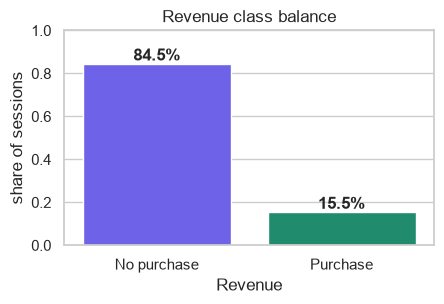

In [4]:
balance = df[TARGET].value_counts(normalize=True).rename({False: "No purchase", True: "Purchase"})
print(balance.round(4).to_string())
print(f"\nmajority-class baseline accuracy: {majority_baseline_accuracy(df[TARGET]):.4f}")

figure, axis = plt.subplots(figsize=(4.6, 3.2))
sns.barplot(x=balance.index, y=balance.to_numpy(), hue=balance.index,
            palette=["#5b4bff", "#0f9d76"], legend=False, ax=axis)
for index, value in enumerate(balance.to_numpy()):
    axis.text(index, value + 0.015, f"{value:.1%}", ha="center", fontweight="bold")
axis.set_ylim(0, 1)
axis.set_ylabel("share of sessions")
axis.set_title("Revenue class balance")
plt.tight_layout()
plt.show()

## 3. Feature types, and why the encoding choice matters

Two traps live in this dataset:

1. **`OperatingSystems`, `Browser`, `Region` and `TrafficType` are stored as integers but are not ordinal.** Browser 4 is not "twice" Browser 2 — the numbers are category labels. Left as raw integers, Logistic Regression would fit a single coefficient to a meaningless ordering and kNN would treat unrelated categories as near neighbours. They are one-hot encoded instead.
2. **The numeric columns live on wildly different scales.** `ProductRelated_Duration` runs into the tens of thousands of seconds while `BounceRates` is bounded in [0, 0.2]. Unscaled, Euclidean distance in kNN is decided almost entirely by the duration columns, and Logistic Regression struggles to converge. They are standardised.

`SpecialDay` stays numeric: its 0.0–1.0 values encode closeness to a special day, so the ordering is real.

Scaling and encoding both happen **inside** each Pipeline, so they are fitted on the training fold only. Fitting a scaler on the full dataset before splitting would leak test-set distribution into training.

In [5]:
print(f"{len(NUMERIC_FEATURES)} numeric features (standardised):")
print(df[NUMERIC_FEATURES].describe().T[["min", "mean", "max"]].round(2).to_string())

print(f"\n{len(CATEGORICAL_FEATURES)} categorical features (one-hot encoded):")
print(
    pd.DataFrame(
        {
            "levels": [df[column].nunique() for column in CATEGORICAL_FEATURES],
            "stored dtype": [str(df[column].dtype) for column in CATEGORICAL_FEATURES],
        },
        index=CATEGORICAL_FEATURES,
    ).to_string()
)

10 numeric features (standardised):
                         min     mean       max
Administrative           0.0     2.32     27.00
Administrative_Duration  0.0    80.82   3398.75
Informational            0.0     0.50     24.00
Informational_Duration   0.0    34.47   2549.38
ProductRelated           0.0    31.73    705.00
ProductRelated_Duration  0.0  1194.75  63973.52
BounceRates              0.0     0.02      0.20
ExitRates                0.0     0.04      0.20
PageValues               0.0     5.89    361.76
SpecialDay               0.0     0.06      1.00

7 categorical features (one-hot encoded):
                  levels stored dtype
Month                 10          str
VisitorType            3          str
Weekend                2         bool
OperatingSystems       8        int64
Browser               13        int64
Region                 9        int64
TrafficType           20        int64


## 4. Correlated features — the evidence against Naive Bayes

Naive Bayes assumes the features are conditionally independent given the class. That assumption is not mildly bent here, it is broken by construction: each page-category column ships alongside a duration column measuring the same browsing behaviour, and `BounceRates`/`ExitRates` are two views of the same bounce phenomenon. Rather than asserting the assumption fails, the correlations below quantify it.

Gaussian NB is used rather than Multinomial: Multinomial NB expects non-negative count-like features, whereas standardisation deliberately produces negative values.

Pearson r for feature pairs that measure the same behaviour:
  Administrative           vs Administrative_Duration    r = 0.602
  Informational            vs Informational_Duration     r = 0.619
  ProductRelated           vs ProductRelated_Duration    r = 0.861
  BounceRates              vs ExitRates                  r = 0.913


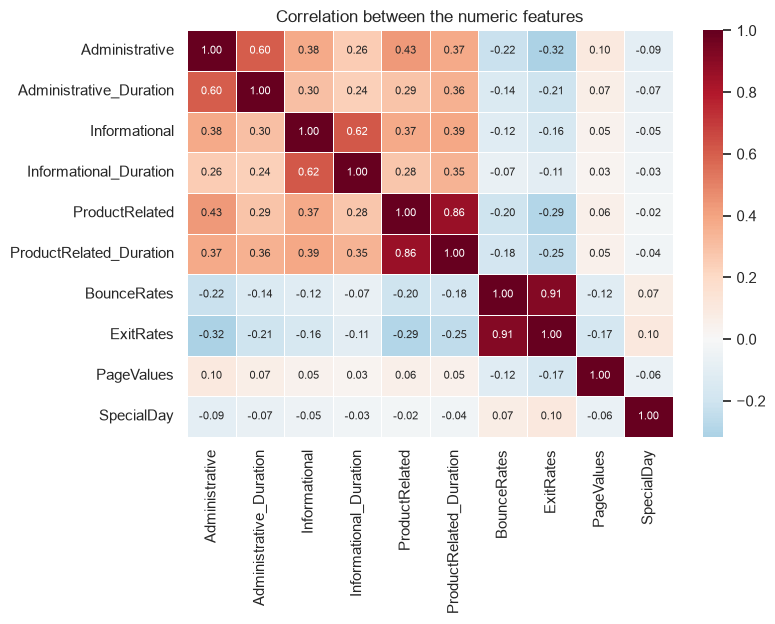

In [6]:
print("Pearson r for feature pairs that measure the same behaviour:")
for left, right in CORRELATED_PAIRS:
    print(f"  {left:<24} vs {right:<26} r = {df[left].corr(df[right]):.3f}")

figure, axis = plt.subplots(figsize=(8.2, 6.4))
sns.heatmap(
    df[NUMERIC_FEATURES].corr(),
    annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    linewidths=0.5, annot_kws={"size": 8}, ax=axis,
)
axis.set_title("Correlation between the numeric features")
plt.tight_layout()
plt.show()

## 5. Stratified train/test split

An 80/20 split stratified on `Revenue`, with a fixed `random_state` so the run is reproducible. Stratification matters at this level of imbalance: a careless random split can shift the positive rate between train and test and quietly change every metric.

In [7]:
X_train, X_test, y_train, y_test = make_split(df)

print(f"train : {len(y_train):>5} rows, positive rate {y_train.mean():.4f}")
print(f"test  : {len(y_test):>5} rows, positive rate {y_test.mean():.4f}")
print(f"\npositive-rate drift between splits: {abs(y_train.mean() - y_test.mean()):.5f}")

train :  9864 rows, positive rate 0.1547
test  :  2466 rows, positive rate 0.1549

positive-rate drift between splits: 0.00020


## 6. Train and evaluate all six classifiers

`train_all()` fits each Pipeline on the training split, scores it on the held-out split, and writes both the pickles and `training_results.json`. AUC is computed from `predict_proba`, never from hard labels — passing 0/1 predictions to `roc_auc_score` collapses the curve to a single operating point and understates every model.

The models are left at near-default settings on purpose. In particular there is **no class weighting** and the Decision Tree is **unconstrained**, so the imbalance problem and the overfitting gap both stay visible in the results instead of being tuned away.

In [8]:
results = train_all()

print(f"\nfeatures after one-hot encoding: {results['n_features_after_encoding']}")

Loaded 12330 rows x 18 columns
Train 9864 rows (positive rate 0.1547)
Test  2466 rows (positive rate 0.1549)
Majority-class baseline accuracy on test: 0.8451

Logistic Regression        Accuracy 0.8808  AUC 0.8828  Precision 0.7366  Recall 0.3586  F1 0.4824  MCC 0.4592  (fit 0.0s)
Decision Tree              Accuracy 0.8621  AUC 0.7410  Precision 0.5538  Recall 0.5654  F1 0.5596  MCC 0.4779  (fit 0.1s)


kNN                        Accuracy 0.8767  AUC 0.7633  Precision 0.6822  Recall 0.3822  F1 0.4899  MCC 0.4493  (fit 0.0s)
Naive Bayes                Accuracy 0.2729  AUC 0.7334  Precision 0.1726  Recall 0.9738  F1 0.2933  MCC 0.1289  (fit 0.0s)


Random Forest (Ensemble)   Accuracy 0.8974  AUC 0.9175  Precision 0.7590  Recall 0.4948  F1 0.5990  MCC 0.5596  (fit 0.4s)


Support Vector Machine     Accuracy 0.8877  AUC 0.8824  Precision 0.7234  Recall 0.4450  F1 0.5511  MCC 0.5099  (fit 4.1s)

features after one-hot encoding: 75


## 7. Comparison table

This is the table reproduced in `README.md`.

In [9]:
comparison = pd.DataFrame(results["metrics"]).T[METRIC_ORDER].round(4)
baseline = results["dataset"]["majority_baseline_accuracy"]

display(comparison.style.highlight_max(axis=0, color="#d8f5e8").format("{:.4f}"))
print(f"majority-class baseline accuracy to beat: {baseline:.4f}")

,Accuracy,AUC,Precision,Recall,F1,MCC
Logistic Regression,0.8808,0.8828,0.7366,0.3586,0.4824,0.4592
Decision Tree,0.8621,0.7410,0.5538,0.5654,0.5596,0.4779
kNN,0.8767,0.7633,0.6822,0.3822,0.4899,0.4493
Naive Bayes,0.2729,0.7334,0.1726,0.9738,0.2933,0.1289
Random Forest (Ensemble),0.8974,0.9175,0.7590,0.4948,0.5990,0.5596
Support Vector Machine,0.8877,0.8824,0.7234,0.4450,0.5511,0.5099


majority-class baseline accuracy to beat: 0.8451


## 8. Accuracy is the wrong ranking metric — the plot that proves it

Plotted against the baseline, four of the six models cluster within a few points of each other on accuracy while their MCC scores spread widely. Naive Bayes is the extreme case: it lands *below* the do-nothing baseline on accuracy, yet its AUC shows it has genuinely learned to rank sessions. The two metrics are answering different questions, and only one of them is a fair ranking here.

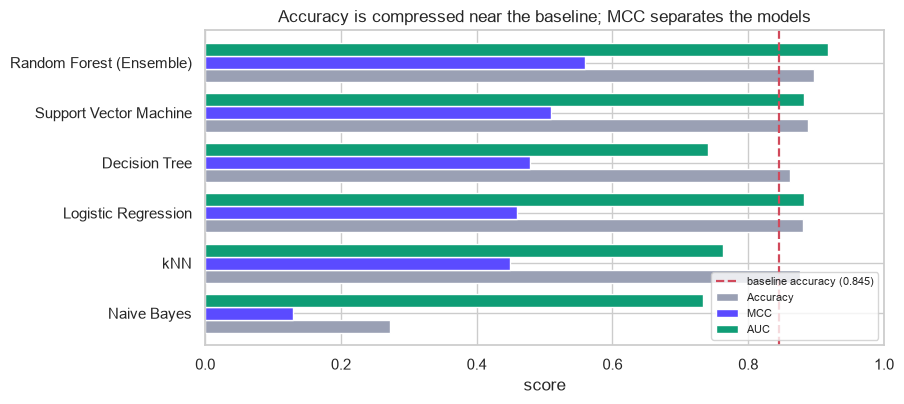

In [10]:
plot_data = comparison[["Accuracy", "MCC", "AUC"]].sort_values("MCC")

figure, axis = plt.subplots(figsize=(9.2, 4.2))
plot_data.plot(kind="barh", ax=axis, color=["#9aa0b4", "#5b4bff", "#0f9d76"], width=0.78)
axis.axvline(baseline, color="#d1495b", linestyle="--", linewidth=1.6,
             label=f"baseline accuracy ({baseline:.3f})")
axis.set_xlim(0, 1)
axis.set_xlabel("score")
axis.set_title("Accuracy is compressed near the baseline; MCC separates the models")
axis.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

## 9. Overfitting check

Training accuracy against test accuracy. The unconstrained Decision Tree memorises the training split perfectly, which is the textbook signature of overfitting and explains why its AUC is the weakest of the tree-based models. The Random Forest also reaches perfect training accuracy, but bagging plus feature subsampling means its test performance does not collapse the same way — that contrast is the clearest single argument for the ensemble.

In [11]:
overfit = pd.DataFrame(results["metrics"]).T[
    ["TrainAccuracy", "Accuracy", "OverfitGap", "FitSeconds"]
].rename(columns={"Accuracy": "TestAccuracy"}).astype(float).round(4)
overfit.sort_values("OverfitGap", ascending=False)

,TrainAccuracy,TestAccuracy,OverfitGap,FitSeconds
Decision Tree,1.0000,0.8621,0.1379,0.053
Random Forest (Ensemble),1.0000,0.8974,0.1026,0.366
kNN,0.9027,0.8767,0.0260,0.009
Support Vector Machine,0.9082,0.8877,0.0205,4.091
Naive Bayes,0.2912,0.2729,0.0182,0.013
Logistic Regression,0.8862,0.8808,0.0054,0.030


## 10. What the Random Forest actually keys on

One feature carries a large share of the total importance: `PageValues`, the average value of the pages a visitor viewed before the session. That concentration explains a lot of the results table — a single strong, monotone predictor is exactly the situation tree ensembles exploit well, and it is also why even a shallow model does respectably here.

It is worth being honest about what `PageValues` is: a Google Analytics metric partly derived from conversion behaviour itself. Its dominance is a reason to be cautious about reading this as a clean causal model of shopper intent.

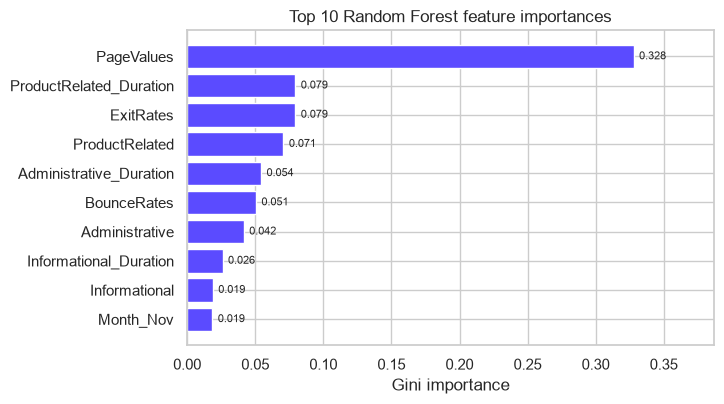

In [12]:
importances = pd.Series(results["random_forest_top_features"]).sort_values()
labels = [name.split("__", 1)[-1] for name in importances.index]

figure, axis = plt.subplots(figsize=(7.4, 4.2))
axis.barh(labels, importances.to_numpy(), color="#5b4bff")
axis.set_xlabel("Gini importance")
axis.set_title("Top 10 Random Forest feature importances")
for index, value in enumerate(importances.to_numpy()):
    axis.text(value + 0.004, index, f"{value:.3f}", va="center", fontsize=8)
axis.set_xlim(0, importances.max() * 1.18)
plt.tight_layout()
plt.show()

## 11. Confusion matrices at the default 0.50 threshold

The confusion matrices make the trade-offs concrete in a way the summary metrics do not. Logistic Regression and kNN are conservative — they flag few sessions as purchases, so precision is high but they miss most real conversions. Naive Bayes does the opposite and flags almost everything. For a retailer deciding who to target with an incentive, those are completely different products, even where the accuracy figures look similar.

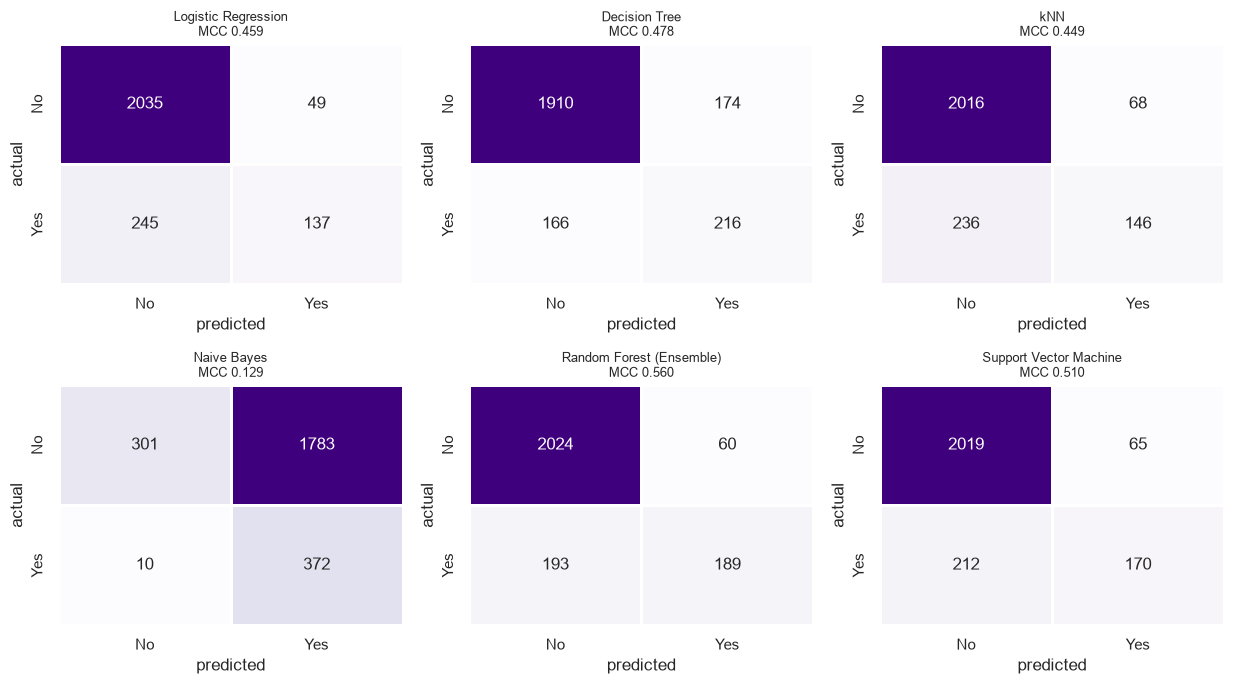

In [13]:
import joblib

from model.config import MODEL_DIR, MODEL_FILENAMES
from model.metrics import confusion_frame, predict_with_proba

figure, axes = plt.subplots(2, 3, figsize=(12.5, 7.0))
for axis, (name, filename) in zip(axes.ravel(), MODEL_FILENAMES.items()):
    pipeline = joblib.load(MODEL_DIR / filename)
    y_pred, _ = predict_with_proba(pipeline, X_test)
    sns.heatmap(
        confusion_frame(y_test, y_pred), annot=True, fmt="d", cmap="Purples",
        cbar=False, linewidths=1.0, linecolor="white", ax=axis,
        xticklabels=["No", "Yes"], yticklabels=["No", "Yes"],
    )
    axis.set_title(f"{name}\nMCC {results['metrics'][name]['MCC']:.3f}", fontsize=9)
    axis.set_xlabel("predicted")
    axis.set_ylabel("actual")
plt.tight_layout()
plt.show()

## 12. Conclusion

Ranked by MCC — the metric that survives a 15.5% positive rate — the Random Forest wins on this dataset, and it wins on AUC as well, so the result is not an artefact of where the decision threshold happens to sit. The cell below prints the final ranking and confirms which models clear the do-nothing baseline.

In [14]:
ranking = comparison.sort_values("MCC", ascending=False)
print("Ranked by MCC\n" + "-" * 62)
for position, (name, row) in enumerate(ranking.iterrows(), start=1):
    beats = "beats baseline" if row["Accuracy"] > baseline else "BELOW baseline"
    print(f"{position}. {name:<26} MCC {row['MCC']:.4f}  AUC {row['AUC']:.4f}  ({beats})")

winner = ranking.index[0]
print("-" * 62)
print(f"Overall winner: {winner}")
print(f"  MCC {ranking.loc[winner, 'MCC']:.4f} | AUC {ranking.loc[winner, 'AUC']:.4f} "
      f"| F1 {ranking.loc[winner, 'F1']:.4f}")

Ranked by MCC
--------------------------------------------------------------
1. Random Forest (Ensemble)   MCC 0.5596  AUC 0.9175  (beats baseline)
2. Support Vector Machine     MCC 0.5099  AUC 0.8824  (beats baseline)
3. Decision Tree              MCC 0.4779  AUC 0.7410  (beats baseline)
4. Logistic Regression        MCC 0.4592  AUC 0.8828  (beats baseline)
5. kNN                        MCC 0.4493  AUC 0.7633  (beats baseline)
6. Naive Bayes                MCC 0.1289  AUC 0.7334  (BELOW baseline)
--------------------------------------------------------------
Overall winner: Random Forest (Ensemble)
  MCC 0.5596 | AUC 0.9175 | F1 0.5990
